In [1]:
!pip install -q tensorflow
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, GlobalMaxPool2D, BatchNormalization, MaxPooling2D
from tensorflow.keras import Model
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print("GPU disponível?", tf.config.list_physical_devices('GPU'))

GPU disponível? [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
cifar10 = tf.keras.datasets.cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data() # matrizes coloridas
x_train, x_test = x_train / 255.0, x_test / 255.0 # normaliza cores
y_train, y_test = y_train.flatten(), y_test.flatten() # transforma em vetor
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(50000, 32, 32, 3) (10000, 32, 32, 3) (50000,) (10000,)


In [4]:
K = len(set(y_train))
print(K)

#buildando o modelo mas agora usando functional API
# cria o modelo de rede neural convolucional
i = Input(shape=x_train[0].shape)

# terceira camada convolucional + normalizacao + dropout
x = Conv2D(32, (3, 3), activation="relu", padding="same")(i)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

# terceira camada convolucional + normalizacao + dropout
x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
# x = Dropout(0.25)(x)

# terceira camada convolucional + normalizacao + dropout
x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
# x = Dropout(0.3)(x)

# camada densa com dropout
x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(1024, activation="relu")(x)
x = Dropout(0.2)(x)

# camada de saida com softmax para classificacao
x = Dense(K, activation="softmax")(x)

# cria o modelo
model = Model(i, x)
print(model)

10
<Functional name=functional, built=True>


In [5]:

# compila o modelo
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=['accuracy'])


In [6]:
# treina o modelo com os dados de treino
r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=8)

Epoch 1/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - accuracy: 0.4489 - loss: 1.7858 - val_accuracy: 0.6405 - val_loss: 1.0336
Epoch 2/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 7ms/step - accuracy: 0.6958 - loss: 0.8656 - val_accuracy: 0.7188 - val_loss: 0.8318
Epoch 3/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.7639 - loss: 0.6854 - val_accuracy: 0.7513 - val_loss: 0.7409
Epoch 4/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8023 - loss: 0.5672 - val_accuracy: 0.7734 - val_loss: 0.6564
Epoch 5/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8384 - loss: 0.4710 - val_accuracy: 0.7931 - val_loss: 0.6158
Epoch 6/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8637 - loss: 0.3970 - val_accuracy: 0.7848 - val_loss: 0.6800
Epoch 7/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8821 - loss: 0.3343 - val_accuracy: 0.8072 - val_loss: 0.6342
Epoch 8/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9043 - loss: 0.2815 -

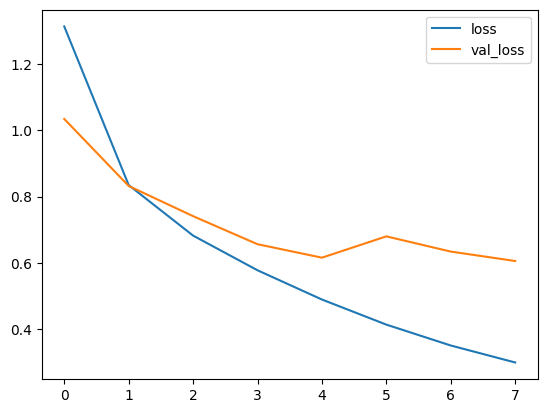

In [7]:
# plota a perda por iteracao
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

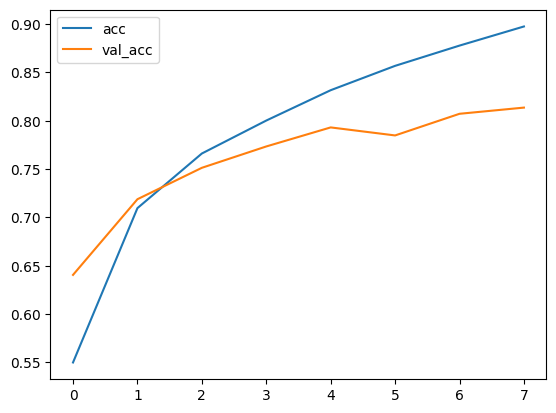

In [8]:
# plota a acuracia por iteracao
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
confusion matrix, without normalization
[[862   9  14  14  15   9   3   6  44  24]
 [ 11 885   0   2   2   3   1   0  22  74]
 [ 56   2 676  48  98  59  34  10  10   7]
 [ 13   2  48 626  78 167  39  19   4   4]
 [  7   1  28  34 866  22  27   9   5   1]
 [ 10   1  30  87  58 779  12  15   2   6]
 [  7   0  27  51  35  25 842   3   8   2]
 [ 10   1  14  21  99  52   1 789   4   9]
 [ 51   8   7   6   7   6   0   1 899  15]
 [ 17  24   2   7   1   1   2   5  29 912]]


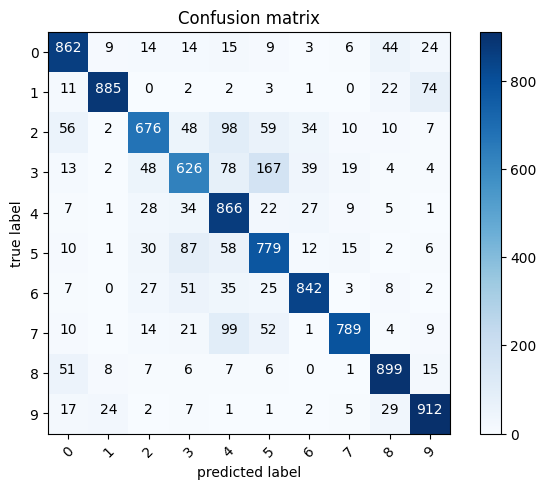

In [9]:
# importa funcoes para matriz de confusao
from sklearn.metrics import confusion_matrix
import itertools

# funcao para plotar matriz de confusao
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
  # normaliza a matriz se necessario
  if normalize:
      cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
      print("normalized confusion matrix")
  else:
      print('confusion matrix, without normalization')

  print(cm)

  # plota a matriz
  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)

  # adiciona os numeros na matriz
  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
      plt.text(j, i, format(cm[i, j], fmt),
               horizontalalignment="center",
               color="white" if cm[i, j] > thresh else "black")

  plt.tight_layout()
  plt.ylabel('true label')
  plt.xlabel('predicted label')
  plt.show()

# gera predicoes no conjunto de teste
p_test = model.predict(x_test).argmax(axis=1)
# calcula a matriz de confusao
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))


# Agora com data augmentation

## É interessante observar uma falha na segunda época, para resolver isso, deixei a propria função fit decidir esse parametro

   1/1562 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9062 - loss: 0.5427/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.


In [29]:
batch_size = 32
data_generator = tf.keras.preprocessing.image.ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1,
                                                           horizontal_flip=True)
train_generator = data_generator.flow(x_train, y_train, batch_size)
steps_per_epoch = x_train.shape[0] // batch_size
r = model.fit(train_generator, validation_data=(x_test, y_test), epochs=10)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.7969 - loss: 0.5892 - val_accuracy: 0.7826 - val_loss: 0.6669
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.8145 - loss: 0.5462 - val_accuracy: 0.8039 - val_loss: 0.6045
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.8237 - loss: 0.5226 - val_accuracy: 0.8253 - val_loss: 0.5286
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.8343 - loss: 0.4891 - val_accuracy: 0.8291 - val_loss: 0.5119
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.8390 - loss: 0.4714 - val_accuracy: 0.8142 - val_loss: 0.5651
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.8468 - loss: 0.4464 - val_accuracy: 0.8467 - val_loss: 0.4661
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.8573 - loss: 0.4202 - val_accuracy: 0.8436 - val_loss: 0.4859
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.8585 -

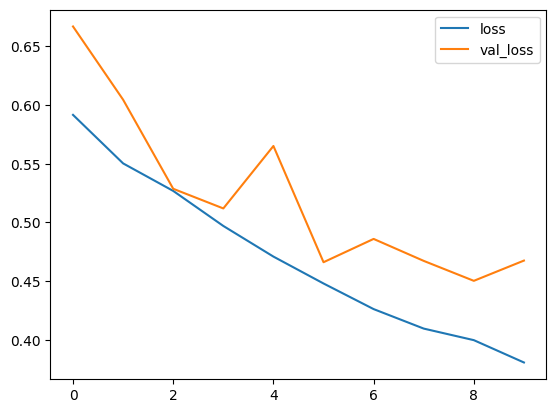

In [30]:
# plota a perda por iteracao
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

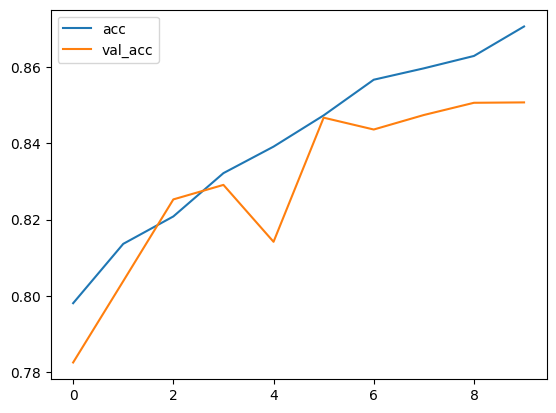

In [31]:
# plota a acuracia por iteracao
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
confusion matrix, without normalization
[[886  11  15   7   2   1   6   4  45  23]
 [  4 969   0   1   0   0   0   0   5  21]
 [ 60   3 777  29  11  30  59  13   7  11]
 [ 26   7  33 643  24 110 108  24  12  13]
 [ 15   4  61  24 743  30  81  29   8   5]
 [ 12   5  17  81  12 776  64  26   4   3]
 [ 11   4  16   9   1   5 950   1   2   1]
 [ 13   2  12  13  10  16  11 917   1   5]
 [ 27  10   2   2   0   0   1   4 942  12]
 [  9  65   2   2   0   0   2   1  15 904]]


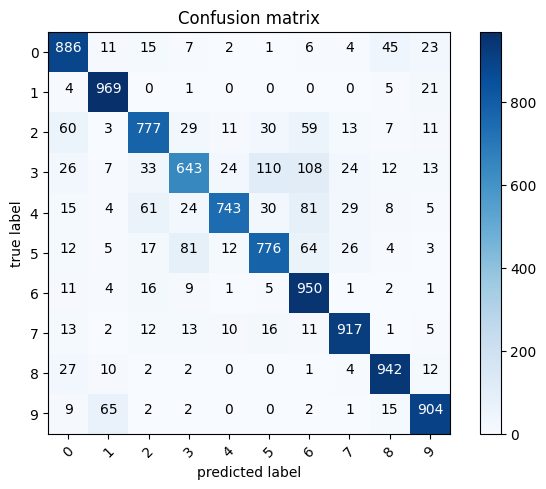

In [32]:
# importa funcoes para matriz de confusao
from sklearn.metrics import confusion_matrix
import itertools

# funcao para plotar matriz de confusao
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
  # normaliza a matriz se necessario
  if normalize:
      cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
      print("normalized confusion matrix")
  else:
      print('confusion matrix, without normalization')

  print(cm)

  # plota a matriz
  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)

  # adiciona os numeros na matriz
  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
      plt.text(j, i, format(cm[i, j], fmt),
               horizontalalignment="center",
               color="white" if cm[i, j] > thresh else "black")

  plt.tight_layout()
  plt.ylabel('true label')
  plt.xlabel('predicted label')
  plt.show()

# gera predicoes no conjunto de teste
p_test = model.predict(x_test).argmax(axis=1)
# calcula a matriz de confusao
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,189,888 (27.43 MB)

 Trainable params: 2,396,330 (9.14 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 4,792,662 (18.28 MB)

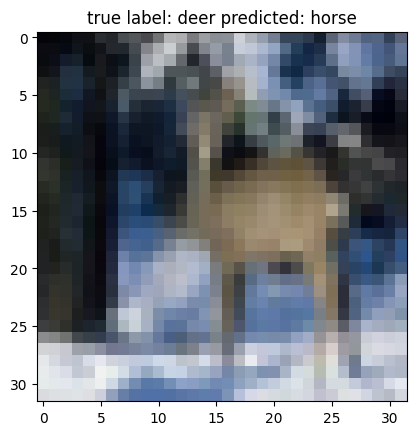

In [33]:
# nomes das classes do cifar10
labels = '''airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck'''.split()

# exemplo de imagem mal classificada
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(x_test[i], cmap='gray')
plt.title("true label: %s predicted: %s" % (labels[y_test[i]], labels[p_test[i]]))

# resumo da arquitetura do modelo
model.summary()